

**Part 2. Lifetime exposure**
- GMT mapping 
- lifetime exposure functions

To do ! 

In [4]:
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import pickle as pk
from scipy import interpolate
import regionmask
import glob, os, re, sys
import openpyxl
import matplotlib.pyplot as plt
import warnings
from math import ceil 
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 20)
%matplotlib inline 

sys.path.append('..')
from gmt_mapping import * 

## 1) Load_GMT()

In [32]:
dir_temperature_trajectories

'/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/demographics4climate/data/temperature-trajectories'

In [60]:
df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS, ds_GMT_STS, df_GMT_strj = load_GMT(
    year_start=1950,
    year_end=2119,
    gmt_extend_method='10yrmean',
)


In [34]:
df_GMT_strj


,1.5,1.6,1.7,1.8,1.9,2.0,2.1,2.2,2.3,2.4,...,2.6,2.7,2.8,2.9,3.0,3.1,3.2,3.3,3.4,3.5
1950,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,...,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417
1951,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,...,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391
1952,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,...,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499
1953,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,...,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225
1954,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,...,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2115,1.537923,1.616544,1.714819,1.803267,1.901543,1.999893,2.098541,2.195396,2.285974,2.383802,...,2.573739,2.664185,2.756641,2.854122,2.946888,3.042389,3.133428,3.231607,3.328001,3.408329
2116,1.537923,1.616544,1.714819,1.803267,1.901543,1.999893,2.098541,2.195396,2.285974,2.383802,...,2.573739,2.664185,2.756641,2.854122,2.946888,3.042389,3.133428,3.231607,3.328001,3.408329
2117,1.537923,1.616544,1.714819,1.803267,1.901543,1.999893,2.098541,2.195396,2.285974,2.383802,...,2.573739,2.664185,2.756641,2.854122,2.946888,3.042389,3.133428,3.231607,3.328001,3.408329
2118,1.537923,1.616544,1.714819,1.803267,1.901543,1.999893,2.098541,2.195396,2.285974,2.383802,...,2.573739,2.664185,2.756641,2.854122,2.946888,3.042389,3.133428,3.231607,3.328001,3.408329


In [5]:
df_GMT_OS.tail(20)

,1.4
2100,1.424
2101,1.414
2102,1.404
2103,1.404
2104,1.404
2105,1.439
2106,1.439
2107,1.439
2108,1.439
2109,1.439


In [7]:
df_GMT_noOS.tail(20)

,1.3
2100,1.344
2101,1.354
2102,1.354
2103,1.354
2104,1.354
2105,1.352
2106,1.352
2107,1.352
2108,1.352
2109,1.352


In [9]:
df_GMT_15.tail(20)


,1.3
2100,1.336467
2101,1.361027
2102,1.361027
2103,1.361027
2104,1.361027
2105,1.361027
2106,1.361027
2107,1.361027
2108,1.361027
2109,1.361027


In [11]:
df_GMT_20.tail(20)

,2.0
2100,1.978587
2101,1.980163
2102,1.980163
2103,1.980163
2104,1.980163
2105,1.980163
2106,1.980163
2107,1.980163
2108,1.980163
2109,1.980163


In [35]:
ds_GMT_STS

<xarray.Dataset>
Dimensions:     (time: 451, percentile: 4, scenario: 4)
Coordinates:
  * time        (time) int64 1850 1851 1852 1853 1854 ... 2297 2298 2299 2300
  * percentile  (percentile) object '50.0' '95.0' '98.0' '99.0'
  * scenario    (scenario) object 'ModAct' 'Ren' 'LD' 'SP'
Data variables:
    tas         (time, percentile, scenario) float64 ...
Attributes:
    Description:  Trajectories of Global Surface Air Temperature for the Stre...
    Model:        FaIRv1.6.4
    Method:       These scenarios were originally designed for the project PR...
    region:       World
    contact:      Yann Quilcaille <yann.quilcaille@env.ethz.ch>

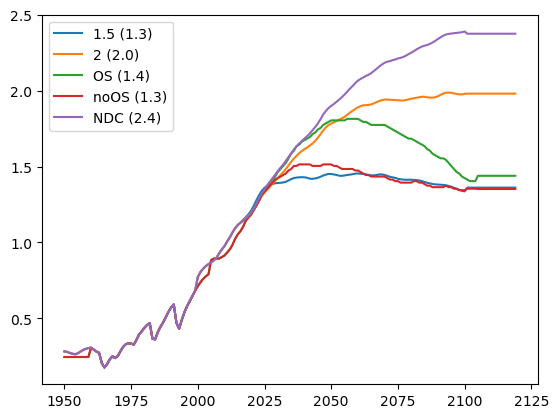

In [12]:
fig, ax = plt.subplots()
labels=['1.5','2','OS', 'noOS', 'NDC']

for i,df in enumerate([df_GMT_15, df_GMT_20,  df_GMT_OS, df_GMT_noOS,df_GMT_NDC ]): #
    df.plot(ax=ax)
    labels[i] = labels[i]+' ('+df.columns.values[0]+')'

ax.legend(labels, loc='upper left')


# issues: 
# 3) other extension methods dont work properly I think.. 

# questions
# how is NDC chosen/set
# how different are the 1.5/2 deg scenariosa nd the strj and how are they made/selected
# how were OS and noOS selected


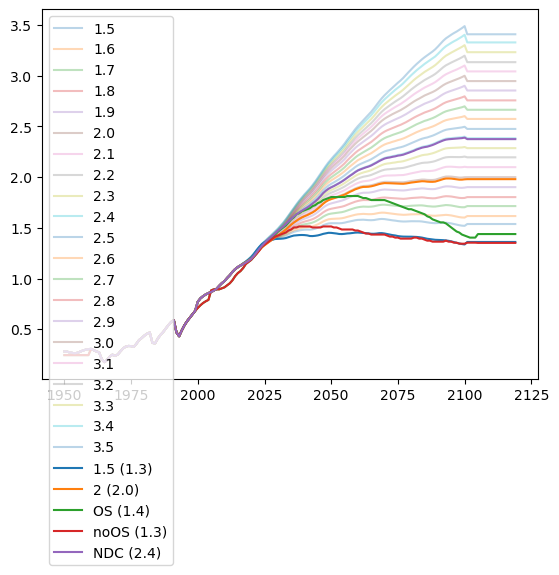

In [ ]:
fig, ax = plt.subplots()

df_GMT_strj.plot(ax=ax, alpha=.3)

labels=['1.5','2','OS', 'noOS', 'NDC']

ax.set_prop_cycle(None) 

for i,df in enumerate([df_GMT_15, df_GMT_20,  df_GMT_OS, df_GMT_noOS,df_GMT_NDC ]): 
    labels[i] = labels[i]+' ('+df.columns.values[0]+')'
    df.squeeze().plot(ax=ax, label=labels[i])

plt.legend(loc='upper left')


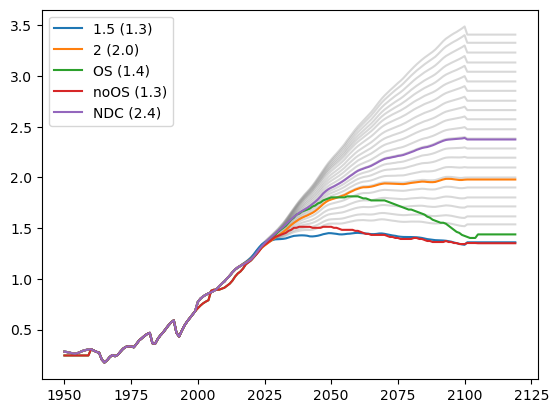

In [61]:
fig, ax = plt.subplots()

# Plot the background lines for df_GMT_strj without adding legend entries
for col in df_GMT_strj.columns:
    ax.plot(df_GMT_strj.index, df_GMT_strj[col], alpha=0.3, color='gray')  # no label

labels = ['1.5', '2', 'OS', 'noOS', 'NDC']

ax.set_prop_cycle(None)

for i, df in enumerate([df_GMT_15, df_GMT_20, df_GMT_OS, df_GMT_noOS, df_GMT_NDC]):
    labels[i] = labels[i] + ' (' + df.columns.values[0] + ')'
    df.squeeze().plot(ax=ax, label=labels[i])

plt.legend(loc='upper left')

In [50]:
df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS, ds_GMT_STS, df_GMT_strj = load_GMT(
    year_start=1950,
    year_end=2119,
    gmt_extend_method='10yrtrend',
)

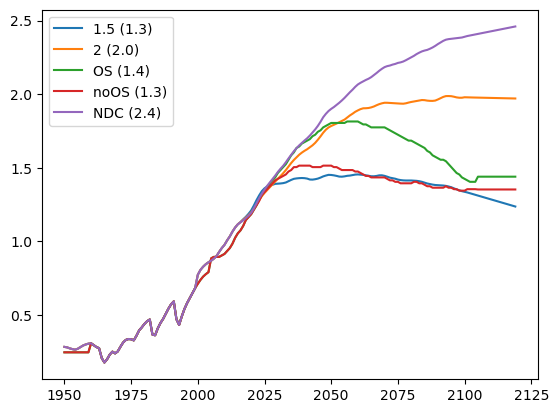

In [51]:
fig, ax = plt.subplots()
labels=['1.5','2','OS', 'noOS', 'NDC']

for i,df in enumerate([df_GMT_15, df_GMT_20,  df_GMT_OS, df_GMT_noOS,df_GMT_NDC ]): #
    df.plot(ax=ax)
    labels[i] = labels[i]+' ('+df.columns.values[0]+')'

ax.legend(labels, loc='upper left')

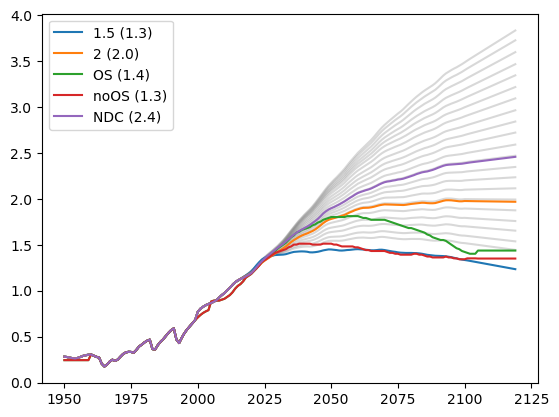

In [59]:
fig, ax = plt.subplots()

# Plot the background lines for df_GMT_strj without adding legend entries
for col in df_GMT_strj.columns:
    ax.plot(df_GMT_strj.index, df_GMT_strj[col], alpha=0.3, color='gray')  # no label

labels = ['1.5', '2', 'OS', 'noOS', 'NDC']

ax.set_prop_cycle(None)

for i, df in enumerate([df_GMT_15, df_GMT_20, df_GMT_OS, df_GMT_noOS, df_GMT_NDC]):
    labels[i] = labels[i] + ' (' + df.columns.values[0] + ')'
    df.squeeze().plot(ax=ax, label=labels[i])

plt.legend(loc='upper left')

In [3]:
## test different extensions

In [4]:

def extend_gmt_to_year_range(df, year_start=1950, year_end=2119, gmt_extend_method=None):
    """
    Extend a GMT time series (Series or DataFrame) to a given year range.
    
    Handles both backward and forward extension using specified method.
    
    Parameters
    ----------
    df : pd.Series or pd.DataFrame
        Input data indexed by year.
    year_start : int, optional
        Earliest year to extend to (fills backward if needed).
    year_end : int, optional
        Latest year to extend to (fills forward if needed).
    gmt_extend_method : {'10yrmean', 'lastyear', '10yrtrend'}, optional
        Method for forward extension beyond the last available year.
    
    Returns
    -------
    pd.DataFrame
        Extended dataset over [year_start, year_end].
    """
    # --- Ensure DataFrame ---
    if isinstance(df, pd.Series):
        df = df.to_frame()
        df.columns = [f"{df.loc[2100].values[0]:.1f}"] if 2100 in df.index else ["value"] # [str(round(df.loc[2100].values[0], 2))] if 2100 in df.index else ["value"]

    df = df.copy()
    df.index = df.index.astype(int)
    
    min_year, max_year = int(np.nanmin(df.index)), int(np.nanmax(df.index))

    # --- Backward extension ---
    if year_start is not None and min_year > year_start:
        first_10y_mean = df.iloc[:10, :].mean()
        for year in range(year_start, min_year):
            df.loc[year] = first_10y_mean
    
    df = df.sort_index()

    # --- Forward extension ---
    if year_end is not None and max_year < year_end:
        if gmt_extend_method == "10yrmean":
            last_10y_mean = df.iloc[-10:, :].mean()
            for year in range(max_year + 1, year_end + 1):
                df.loc[year] = last_10y_mean

        elif gmt_extend_method == "lastyear":
            last_year_vals = df.iloc[-1, :]
            for year in range(max_year + 1, year_end + 1):
                df.loc[year] = last_year_vals

        elif gmt_extend_method == "10yrtrend":
            yrs = np.arange(max_year - 9, max_year + 1)
            trends = {col: np.polyfit(yrs, df.loc[yrs, col].astype(float), 1) for col in df.columns}
            for year in range(max_year + 1, year_end + 1):
                df.loc[year] = {col: np.polyval(trends[col], year) for col in df.columns}

    # --- Sort index and restrict range ---
    df = df.sort_index()
    if year_start is not None or year_end is not None:
        df = df.loc[
            (df.index >= (year_start if year_start is not None else df.index.min())) &
            (df.index <= (year_end if year_end is not None else df.index.max()))
        ]

    return df

In [14]:
from scipy.io import loadmat

# Load GMT_OS
mat_data = loadmat(dir_temperature_trajectories + '/temperature-trajectories_Wim/GMT_OS.mat', squeeze_me=True)
GMT_OS = mat_data['GMT_OS'].flatten()
years = np.arange(1960, 1960 + len(GMT_OS))
df_GMT_OS = pd.Series(GMT_OS, index=years)
df_GMT_OS.name = None
df_GMT_OS.index.name = None

# Load GMT_noOS
mat_data = loadmat(dir_temperature_trajectories + '/temperature-trajectories_Wim/GMT_noOS.mat', squeeze_me=True)
GMT_noOS = mat_data['GMT_noOS'].flatten()
years = np.arange(1960, 1960 + len(GMT_noOS))
df_GMT_noOS = pd.Series(GMT_noOS, index=years)
df_GMT_noOS.name = None
df_GMT_noOS.index.name = None



In [16]:
df_GMT_OS

1960    0.306832
1961    0.293686
1962    0.281428
1963    0.273481
1964    0.206345
          ...   
2109    1.439000
2110    1.439000
2111    1.439000
2112    1.439000
2113    1.439000
Length: 154, dtype: float64

<Axes: >

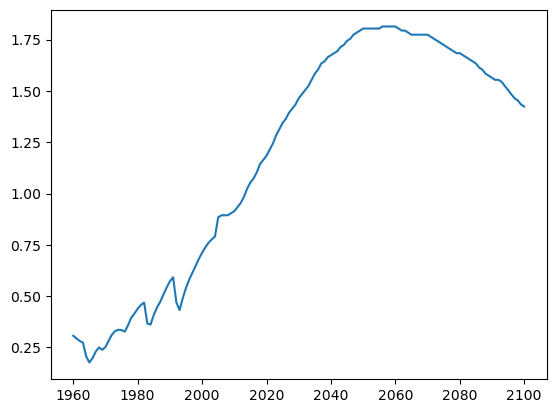

In [ ]:
df_GMT_OS.loc[:2100].plot() # try extending OS with trend - too much no?

In [27]:
df_GMT_OS = extend_gmt_to_year_range(df_GMT_OS.loc[:2100],1950, 2119, gmt_extend_method='lastyear')
df_GMT_noOS = extend_gmt_to_year_range(df_GMT_noOS.loc[:2100],1950,2119, gmt_extend_method='lastyear')

<Axes: >

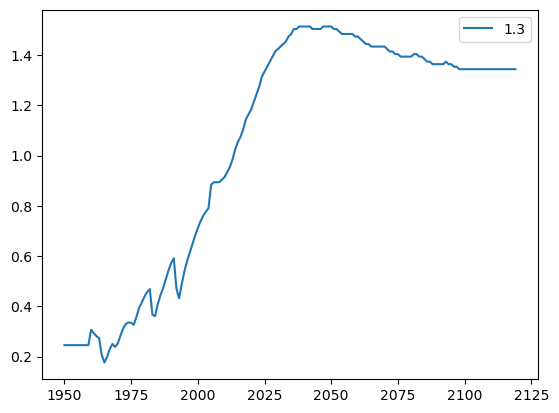

In [28]:
df_GMT_noOS.plot()

<Axes: >

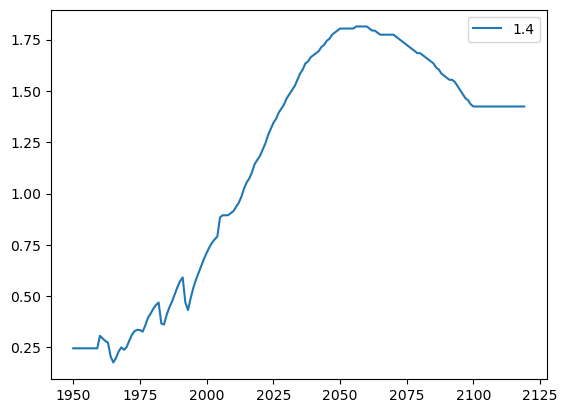

In [29]:
df_GMT_OS.plot()

In [39]:
year_start=1950

# collect new ar6 scens from IASA explorer
df_GMT_ar6 = pd.read_csv(dir_temperature_trajectories+'/temperature-trajectories_AR6/ar6_c1_c7_nogaps_2000-2100.csv',header=0)
df_GMT_ar6.loc[:,'Model'] = df_GMT_ar6.loc[:,'Model']+'_'+df_GMT_ar6.loc[:,'Scenario']
df_GMT_ar6 = df_GMT_ar6.drop(columns=['Scenario','Region','Variable','Unit']).transpose()
df_GMT_ar6.columns=df_GMT_ar6.loc['Model',:]
df_GMT_ar6.columns.name = None
df_GMT_ar6 = df_GMT_ar6.drop(df_GMT_ar6.index[0])
df_GMT_ar6 = df_GMT_ar6.dropna(axis=1)
df_GMT_ar6.index = df_GMT_ar6.index.astype(int)
df_hist_all = df_GMT_15.loc[year_start:1999]
df_hist_all = pd.concat([df_hist_all for i in range(len(df_GMT_ar6.columns))],axis=1)
df_hist_all.columns = df_GMT_ar6.columns
df_GMT_ar6 = pd.concat([df_hist_all,df_GMT_ar6],axis=0) # add historical values to additional scenarios

# drop dups
df_GMT_ar6 = df_GMT_ar6[~df_GMT_ar6.index.duplicated(keep='first')]

# get new trajects - this overwrites the above df_GMT_15
df_GMT_lb, df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_30, df_GMT_40 = ar6_scen_grab(
    scen_thresholds,
    df_GMT_ar6,
)  

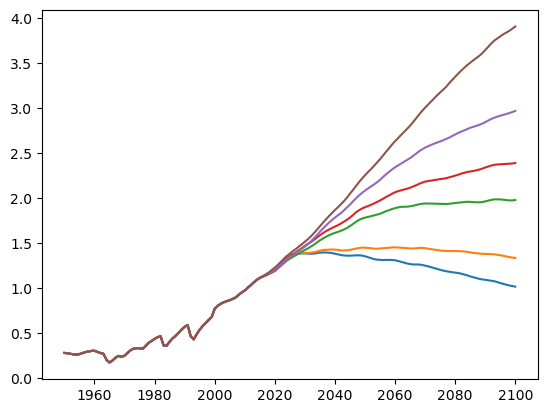

In [ ]:
fig, ax = plt.subplots()

for df in [df_GMT_lb, df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_30, df_GMT_40]:
    df.plot()

# ar6_scen_grab takes lowest highest and some in the middle, then later interpolates between all of these to have regularly spaced at 0.1 deg intervals in 2100

<Axes: >

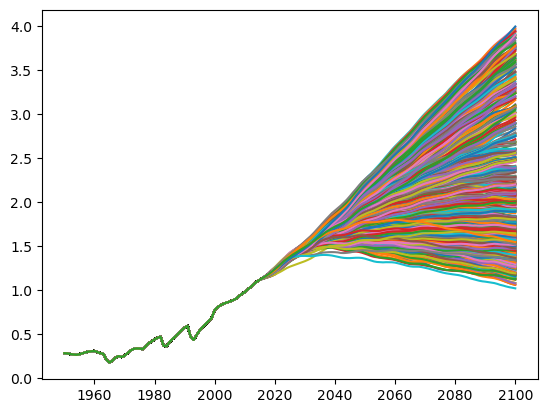

In [ ]:
df_GMT_ar6.plot(legend=False)

# all the input scenarios, with one pathway until 1999 

# 2) Load_ISIMIP

Develop how to load data and GMT-mapping metadata

In [1]:

GCMs = ['ACCESS-CM2', 'CNRM-ESM2-1', 'CanESM5', 'EC-EARTH', 'MPI-ESM1-2-HR', 'MRI-ESM2-0']
scenarios = ['historical', 'ssp126', 'ssp245', 'ssp370', 'ssp585']

extremes="FWI95d" # e.g. "FWI95d"
model_names = GCMs
climatedata_dir = '/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI' # structure should be climatedata_dir/scenario/model
scenarios = scenarios
df_GMT_strj = None # add also others! loop over them ! add labels 

smoothing=True
rolling_window=21

model_gmst_dir = None # need this!! and prep the GMST 

gmt_mapping_method = 'year-to-year' 

In [2]:
extreme = extremes
model=model_names[0]
scenario=scenarios[0]

In [6]:
# initialise counter, metadata dictionary, pic list, pic meta, and 
i = 1
d_climate_data_meta = {}

In [8]:
filepath = glob.glob(os.path.join(climatedata_dir, scenario, model, f'*{model}*{extreme}.nc'))[0]
print(f'Loading {filepath}')

# load data: annual count of exceedances of threshold (already preprocessed)
da_ssp = xr.open_dataarray(filepath)

# save metadata
d_climate_data_meta[i] = {
    'extreme': extreme,
    'model': model,
    'scenario': scenario,
}

#load associated historical variable
filepath_hist = glob.glob(os.path.join(climatedata_dir, 'historical', model, f'*{model}*{extreme}.nc'))[0]
da_hist = xr.open_dataarray(filepath_hist)

Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc


In [11]:
da_ssp.drop('quantile')

<xarray.DataArray 'FWI95d' (time: 65, latitude: 392, longitude: 500)>
[12740000 values with dtype=int64]
Coordinates:
  * longitude  (longitude) float64 -14.96 -14.86 -14.76 ... 34.74 34.84 34.94
  * latitude   (latitude) float64 71.09 70.99 70.89 70.79 ... 32.19 32.09 31.99
  * time       (time) datetime64[ns] 1950-12-31 1951-12-31 ... 2014-12-31